In [1]:
import sys
sys.path.append("../")
from src.models import VAE
from src.priors import *
from src.algorithms.algorithms import ParticleML
from src.algorithms.other_discretizations import ParticleML_One
from src.preconditioners import ConstantPreconditioner
import torch
from torch.utils.data import TensorDataset, DataLoader
from src.utils import dataset_with_indices
import matplotlib.pyplot as plt
from IPython.display import clear_output
from src.problems import *
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib
# font options
font = {
    #'family' : 'normal',
    #'weight' : 'bold',
    'size'   : 22
}

plt.rc('font', **font)
plt.rc('lines', linewidth=2)
plt.rcParams['text.usetex'] = True
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
def show(model, test):
    model = model.cpu().detach().numpy()
    test = test.cpu().detach().numpy()
    plt.clf()
    plt.hist(model, alpha=0.5, label="model", bins=100, density=True)
    plt.hist(test, alpha=0.5, label="test", bins=100, density=True)
    plt.legend()
    plt.show()
def emp_w1(sample1, sample2, ts):
    sample1 = sample1.cpu().detach().numpy()
    sample2 = sample2.cpu().detach().numpy()
    def ecdf(sample, x):
        return np.sum(sample < x)/ sample.shape[0]
    sample1_ecdf = lambda x: ecdf(sample1, x)
    sample2_ecdf = lambda x: ecdf(sample2, x)
    acc = 0
    for i in range(len(ts) - 1):
        dt = ts[i+1] - ts[i]
        diff = sample1_ecdf(ts[i]) - sample2_ecdf(ts[i])
        acc = acc + np.abs(diff) / 2 * dt
    return acc

In [4]:
## Data Mixture
means = [-2., 2,] 
n_train = 100
n_test = 100
batch_size = 100
y_dim = 1
latent_dim = 10
theta_step_size = 1e-3
q_step_size = 1e-4
n_epoch = 1000
DEVICE="cuda"
N_REPEATS=10

In [5]:
# Data Generating Process
dgp = ToyGMM(means=means)
def choose_eta(gamma,
               momentum=0.9,
               step_size=1e-3,):
    eta = (1 - momentum) / gamma / step_size
    return eta

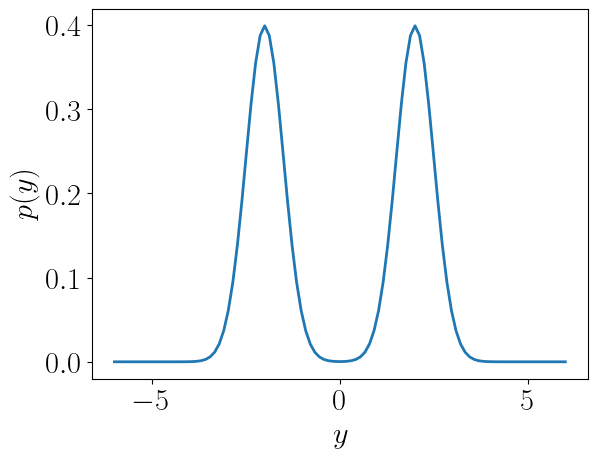

In [6]:
x_lin = torch.linspace(-6, 6, steps=100)
y_lin = dgp.gmm.log_prob(x_lin.unsqueeze(-1)).exp()
plt.plot(x_lin, y_lin)
plt.ylabel("$p(y)$")
plt.xlabel("$y$")
plt.savefig("pdf.pdf", bbox_inches='tight')

In [7]:
n_particles=20
gamma_theta = 0.4
gamma_x = 0.4
t_momentum=0.1
q_momentum=0.1
trainer = lambda model, q_step_size, theta_step_size, acc_theta, acc_x, preconditioner,  : ParticleML_One(model,
                                                                       theta_step_size=theta_step_size,
                                                                       q_step_size=q_step_size,
                                                                       train_size=n_train,
                                                                       eval_size=0,
                                                                       n_particles=n_particles,
                                                                       gamma_theta=gamma_theta,
                                                                       eta_theta=choose_eta(gamma_theta, t_momentum, theta_step_size),
                                                                       gamma_x=gamma_x,
                                                                       eta_x=choose_eta(gamma_x, q_momentum, q_step_size),
                                                                       acc_theta=acc_theta,
                                                                       preconditioner=preconditioner,
                                                                       acc_x=acc_x,
                                                                       device=DEVICE)

In [8]:
def train(trainer, dataloader, test_samples):
    losses = []
    ws = []
    for epoch in range(n_epoch):
        epoch_loss = 0
        for i, (samples, idx) in enumerate(dataloader):
            samples = torch.concat(samples, dim=-1)
            loss = trainer.step(samples.to(DEVICE), idx)
            epoch_loss += loss / len(dataloader)
        losses.append(epoch_loss)
        model_samples, latent = trainer.model.sample(1000)
        w1 = emp_w1(model_samples, test_samples, np.linspace(-6, 6))
        ws.append(w1)
    show(model_samples, test_samples)
    return losses, ws

140


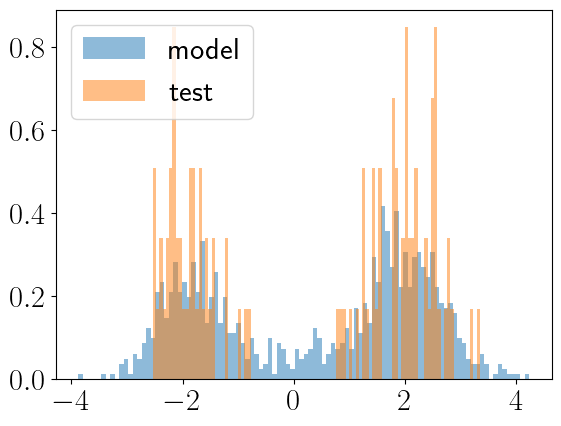

140


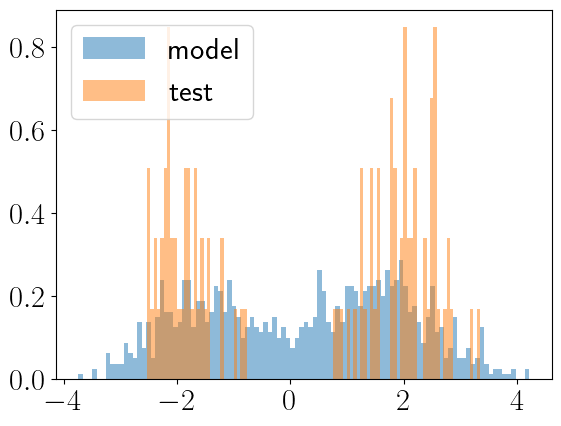

140


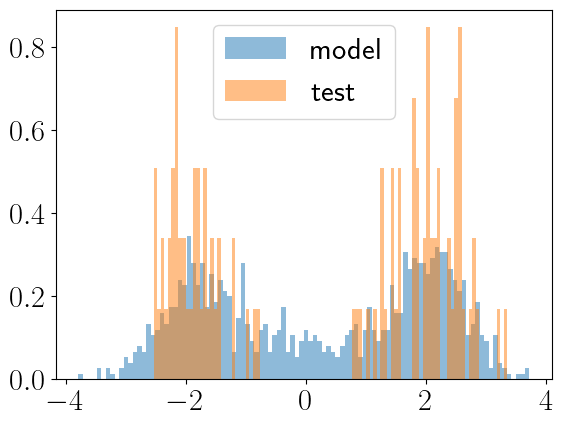

140


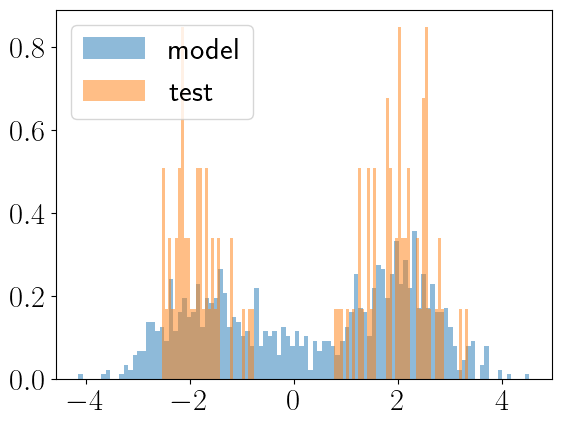

141


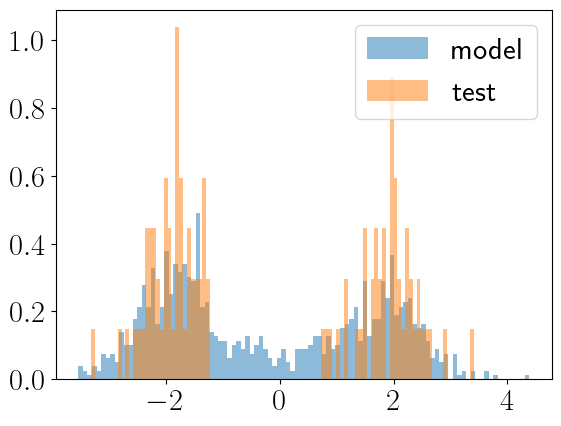

141


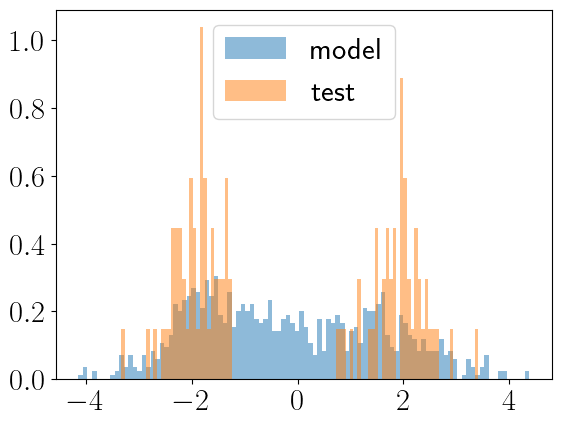

141


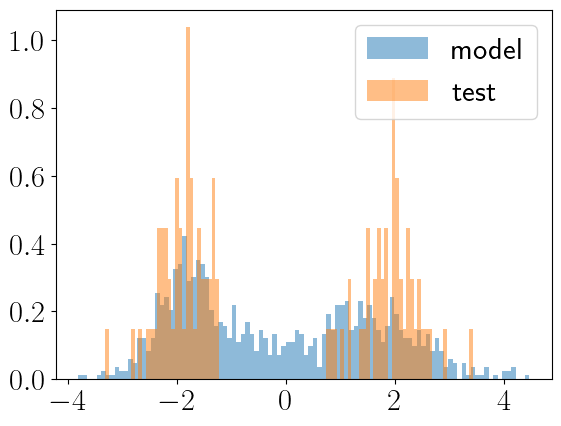

141


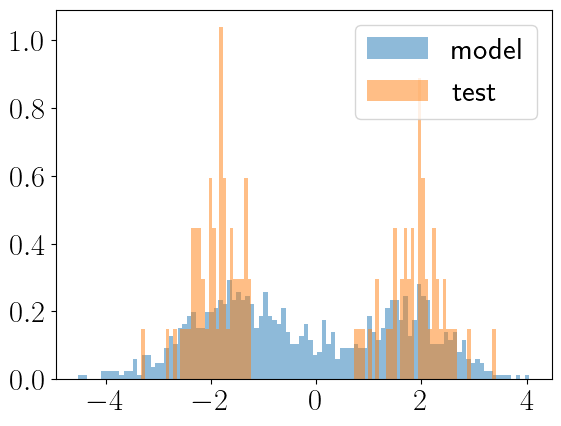

142


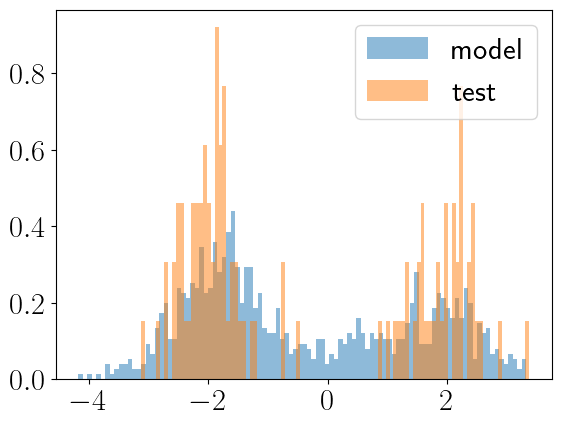

142


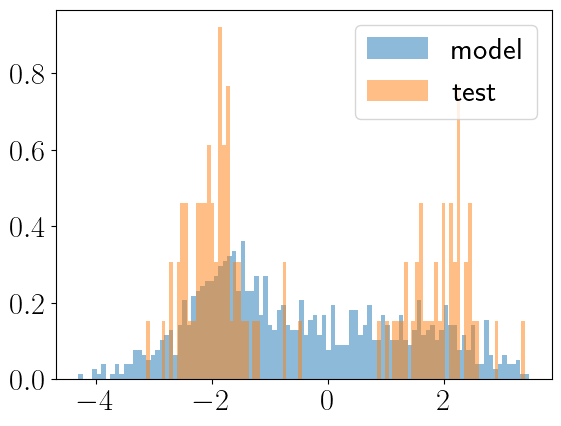

142


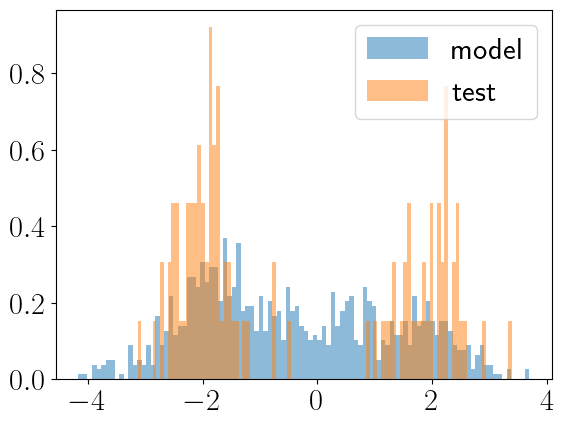

142


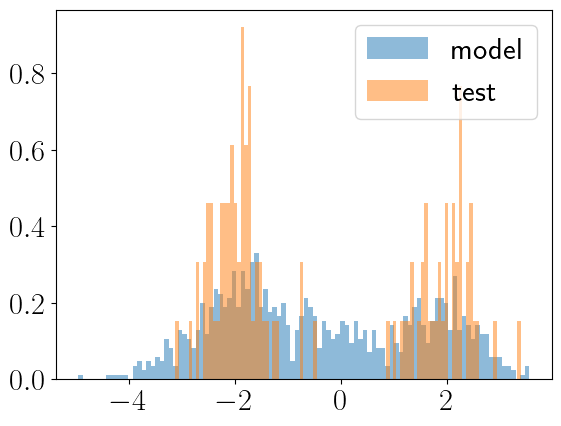

143


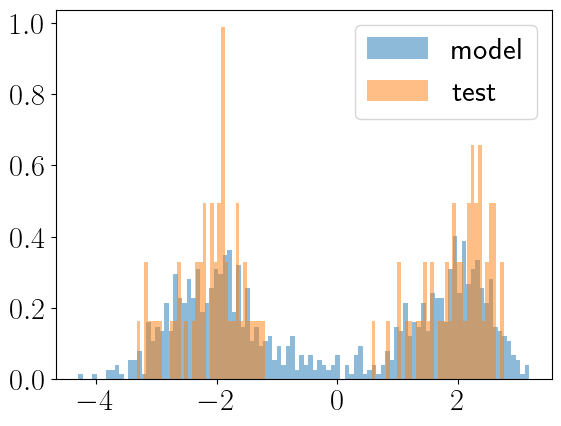

143


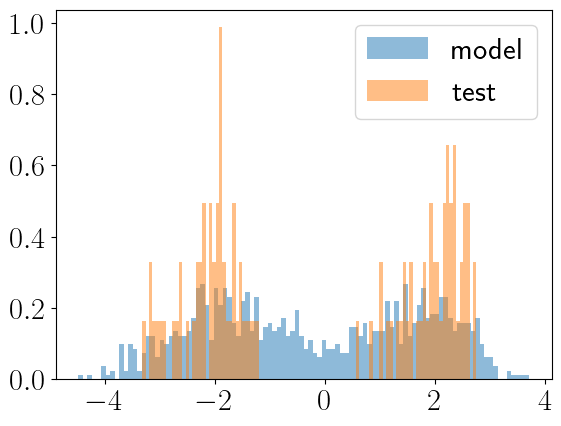

143


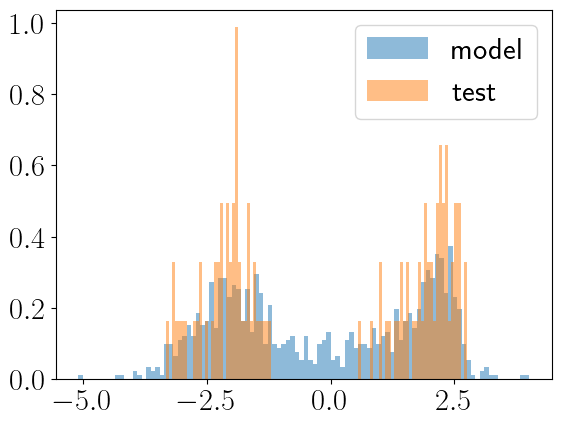

143


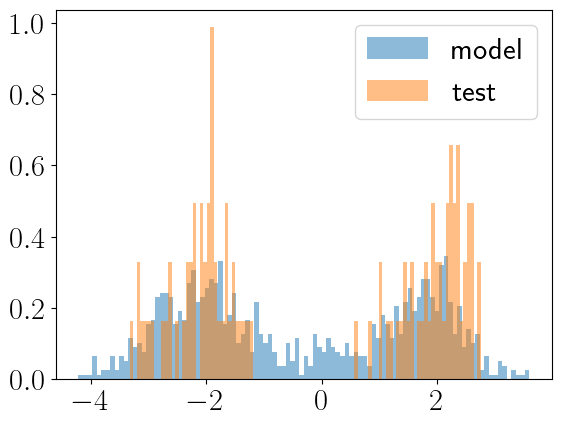

144


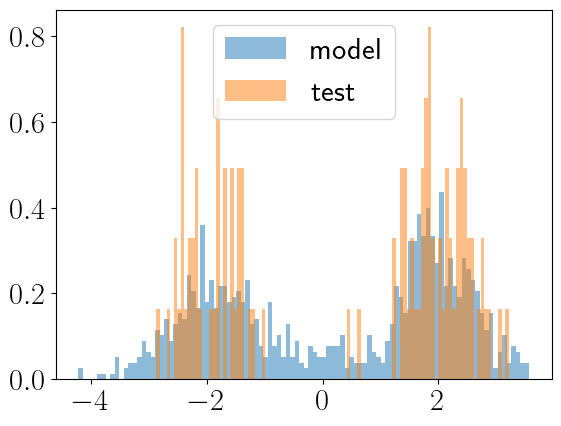

144


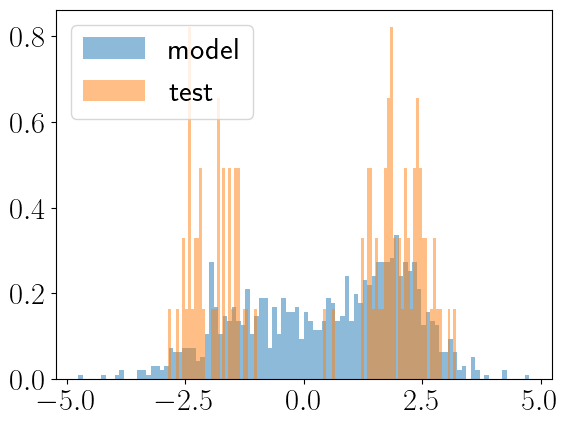

144


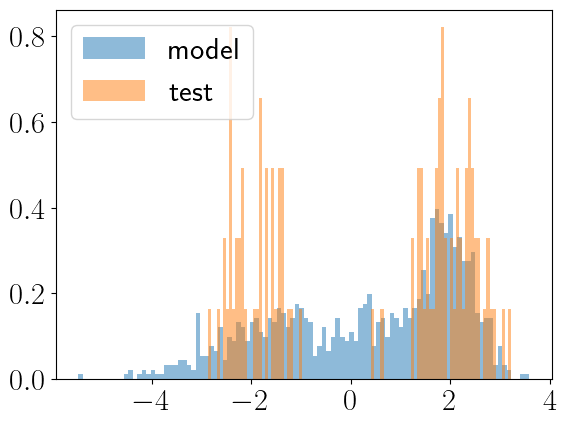

144


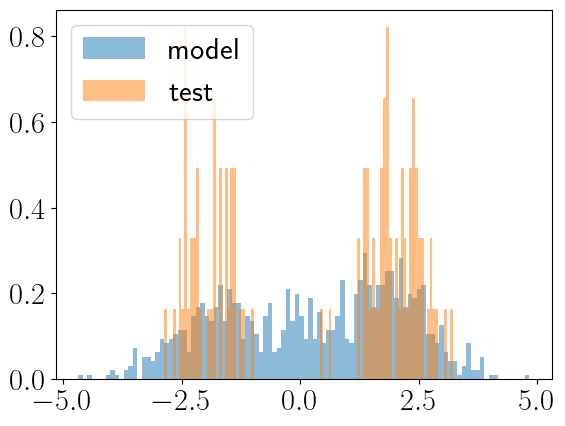

145


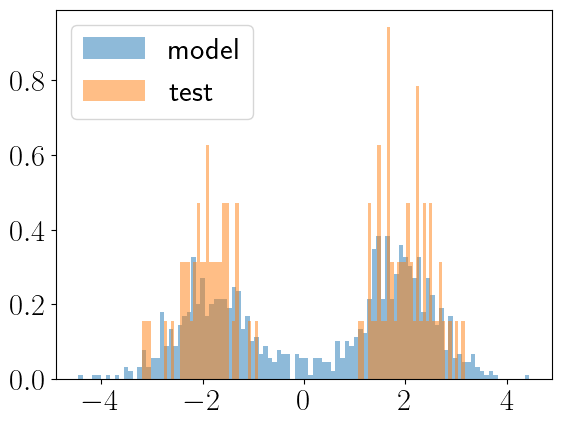

145
145
145


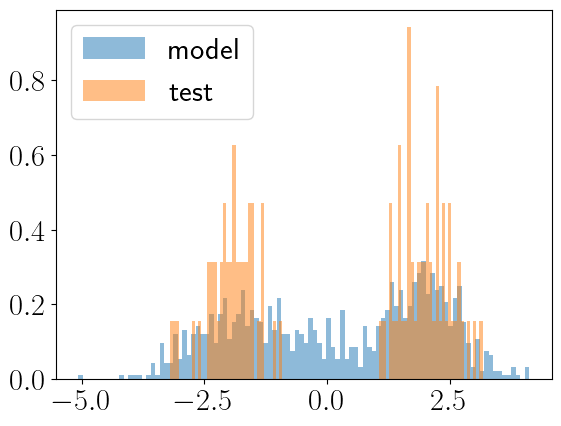

146


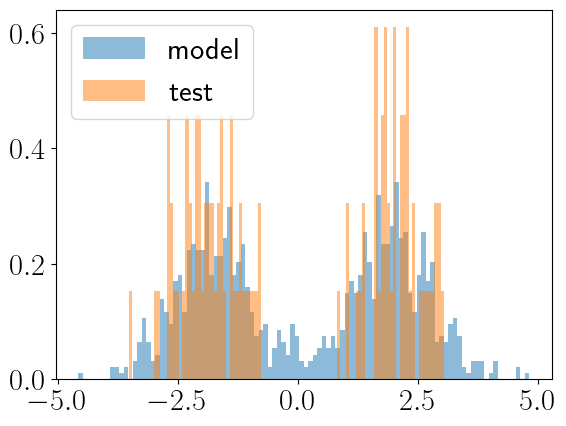

146


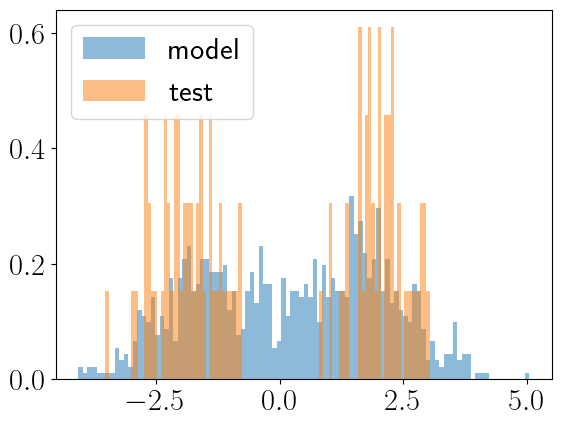

146


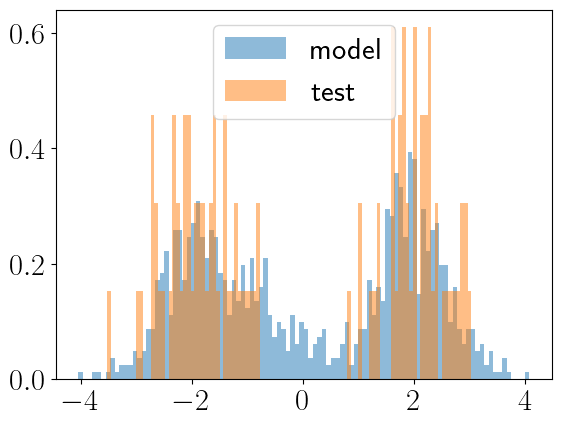

146


In [ ]:
def repeat_n_collect(seed, trainer_inst, q_step_size, theta_step_size, acc_theta, acc_x):
    torch.manual_seed(seed)
    prior = VAMPVarPrior(latent_dim,
                  20,
                  2,
                  device=DEVICE)
    model = VAE(y_dim,
                latent_dim,
                1e-2,
                prior=prior,
                device=DEVICE)
    train_samples = dgp.sample(n_train, seed)
    preconditioner = ConstantPreconditioner(model, c=n_train)
    train_dataset = dataset_with_indices(TensorDataset)(train_samples)
    train_dl = DataLoader(train_dataset, batch_size=n_train)
    test_samples = dgp.sample(n_test, seed)
    
    trainer = trainer_inst(model, q_step_size, theta_step_size, acc_theta, acc_x, preconditioner)
    try:
        losses, ws = train(trainer, train_dl, test_samples)
    except:
        return None
    return losses, ws
seeds = range(140, 140+N_REPEATS)

# pgd_t = np.array([repeat_n_collect(i, parem_trainer, step_size, step_size, None, None) for i in seeds])
# aparem_t = np.array([repeat_n_collect(i, atrainer, step_size, step_size, None, None) for i in seeds])
acc_acc = []
gd_gd = []
acc_gd = []
gd_acc = []
for i in seeds:
    res1 = repeat_n_collect(i, trainer, q_step_size, theta_step_size, True, True)
    res2 = repeat_n_collect(i, trainer, q_step_size, theta_step_size, False, False)
    res3 = repeat_n_collect(i, trainer, q_step_size, theta_step_size, True, False)
    res4 = repeat_n_collect(i, trainer, q_step_size, theta_step_size, False, True)
    if res1 is not None:
        acc_acc.append(res1)
    if res2 is not None:
        gd_gd.append(res2)
    if res3 is not None:
        acc_gd.append(res3)
    if res4 is not None:
        gd_acc.append(res4)

# aparem_rms = np.array([repeat_n_collect(i, aparem_trainer, 'rms', step_size, step_size) for i in seeds])
# aparem_nadam = np.array([repeat_n_collect(i, aparem_trainer, 'nadam', step_size, step_size) for i in seeds])

In [15]:
acc_acc = np.array(acc_acc)
gd_gd = np.array(gd_gd)
acc_gd = np.array(acc_gd)
gd_acc = np.array(gd_acc)

gd_gd_mu = gd_gd.mean(0)
acc_gd_mu = acc_gd.mean(0)
gd_acc_mu = gd_acc.mean(0)
acc_acc_mu = acc_acc.mean(0)

gd_gd_std = gd_gd.std(0)
acc_gd_std = acc_gd.std(0)
gd_acc_std = gd_acc.std(0)
acc_acc_std = acc_acc.std(0)
# gd_test_mu = pgd_t.mean(0)
# ad_test_mu = aparem_t.mean(0)
# aparem_nadam_mu = aparem_nadam.mean(0)
# aparem_rms_mu = aparem_rms.mean(0)

In [ ]:
x_lin = range(len(acc_acc_mu[0]))
plt.errorbar(x_lin, gd_gd_mu[0], gd_gd_std[0], alpha=0.1, color='black')
plt.errorbar(x_lin,acc_gd_mu[0], acc_gd_std[0], alpha=0.1, color='green')
plt.errorbar(x_lin,gd_acc_mu[0], gd_acc_std[0], alpha=0.1, color='purple')
plt.errorbar(x_lin, acc_acc_mu[0], acc_acc_std[0], alpha=0.1, color='blue')

plt.plot(x_lin, gd_gd_mu[0], color='black', label="GD_GD")
plt.plot(x_lin, acc_gd_mu[0], color='green', label="AD_GD")
plt.plot(x_lin, gd_acc_mu[0], color='purple', label="GD_AD")
plt.plot(x_lin, acc_acc_mu[0], color='blue', label="AD_AD")

plt.legend()
plt.xlabel(r"$k$")
plt.savefig("elbo.pdf")

In [ ]:
x_lin = range(len(acc_acc_mu[0]))
skip = 1
alpha = 0.05
capsize = 2
plt.errorbar(x_lin, gd_gd_mu[1], gd_gd_std[1]  , alpha=alpha, color='black',barsabove=True,capsize=capsize, errorevery=skip)
plt.errorbar(x_lin, acc_gd_mu[1], acc_gd_std[1], alpha=alpha, color='green',barsabove=True,capsize=capsize, errorevery=skip)
plt.errorbar(x_lin, gd_acc_mu[1], gd_acc_std[1] , alpha=alpha, color='purple',barsabove=True,capsize=capsize, errorevery=skip)
plt.errorbar(x_lin, acc_acc_mu[1], acc_acc_std[1] , alpha=alpha, color='blue',barsabove=True,capsize=capsize, errorevery=skip)

plt.plot(x_lin, gd_gd_mu[1], color='black', label=r"$\theta$: GD, $\cal{P(X)}$: GD")
plt.plot(x_lin,acc_gd_mu[1], color='green', label=r"$\theta$: MD,   $\cal{P(X)}$: GD")
plt.plot(x_lin,gd_acc_mu[1], color='purple', label=r"$\theta$: GD, $\cal{P(X)}$: MD")
plt.plot(x_lin, acc_acc_mu[1], color='blue', label=r"$\theta$: MD, $\cal{P(X)}$: MD")

plt.legend()
plt.ylabel("$\hat{\sf{W}}_1$")
plt.xlabel("$k$")
plt.savefig("w1_std_dev.pdf", bbox_inches='tight')

In [ ]:
x_lin = range(len(acc_acc_mu[0]))
skip = 1
alpha = 0.05
capsize = 2
plt.errorbar(x_lin, gd_gd_mu[1], gd_gd_std[1] / gd_gd.shape[0] ** 0.5, alpha=alpha, color='black',barsabove=True,capsize=capsize, errorevery=skip)
plt.errorbar(x_lin, acc_gd_mu[1], acc_gd_std[1]/ acc_gd.shape[0] ** 0.5, alpha=alpha, color='green',barsabove=True,capsize=capsize, errorevery=skip)
plt.errorbar(x_lin, gd_acc_mu[1], gd_acc_std[1] / gd_acc.shape[0] ** 0.5, alpha=alpha, color='purple',barsabove=True,capsize=capsize, errorevery=skip)
plt.errorbar(x_lin, acc_acc_mu[1], acc_acc_std[1]/ acc_acc.shape[0]  ** 0.5, alpha=alpha, color='blue',barsabove=True,capsize=capsize, errorevery=skip)

plt.plot(x_lin, gd_gd_mu[1], color='black', label=r"$\theta$: GD, $\cal{P(X)}$: GD")
plt.plot(x_lin,acc_gd_mu[1], color='green', label=r"$\theta$: MD,   $\cal{P(X)}$: GD")
plt.plot(x_lin,gd_acc_mu[1], color='purple', label=r"$\theta$: GD, $\cal{P(X)}$: MD")
plt.plot(x_lin, acc_acc_mu[1], color='blue', label=r"$\theta$: MD, $\cal{P(X)}$: MD")

# plt.plot(gd_test_mu[1], label="GD_T")
# plt.plot(ad_test_mu[1], label="AD_T")
# plt.plot(aparem_rms_mu[1], label="RMS_AGD")
# plt.plot(aparem_nadam_mu[1], label="Adam_AGD")
# plt.legend()
plt.ylabel("$\hat{\sf{W}}_1$")
plt.xlabel("$k$")
plt.savefig("w1_std_err.pdf", bbox_inches='tight')

## 